# "Buy the travel upcycle" — does hotel RevPAR momentum lead hotel stocks? 🏨
### The lodging industry's favourite demand gauge — RevPAR — put to the test, in plain English

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Fragile](https://img.shields.io/badge/Tradability-Fragile-dab617?style=flat-square)
![Leading_indicator%3F: Busted](https://img.shields.io/badge/Leading_indicator%3F-Busted-8b949e?style=flat-square)

Every hotel desk watches **RevPAR** — *Revenue Per Available Room*, the room rate times how full the hotels are. STR / CoStar publish it monthly and it's *the* number for the travel cycle. The folklore is simple: *when RevPAR momentum turns up — travel's booming, rooms are full and pricey — buy hotel REITs, because the good news isn't fully priced yet.*

It sounds like a clean leading signal. But a hotel stock is a bet on **future** room revenue, so its price should move *before* the RevPAR headline, not after. And by the time the industry is bragging about fat year-on-year RevPAR gains, you might be **late in the cycle**, not early. This notebook checks which way the arrow actually points.

> 📓 **Plain-language layer.** Want the *t*-stats, the HAC regression, the placebo test, the Sharpe race and the power control? See **[02_for_the_quants.ipynb](02_for_the_quants.ipynb)**.
>
> ⚠️ **A data note up front.** STR's monthly RevPAR tape is **proprietary** (paywalled), so we build a small, clearly-labelled **proxy**: an approximate monthly U.S. RevPAR path anchored to STR/CoStar-reported **annual** figures, with realistic hotel seasonality and the 2020 COVID crash / 2021 recovery set to the reported national numbers. We call it a proxy throughout, and everything rides on the travel cycle's *shape*, not any single month's exact dollar. Every chart is drawn by the code beside it; house style in [METHODOLOGY.md](../../../METHODOLOGY.md).

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from hotel_revpar import data, strategy as st

HAVE_REAL = data.have_real()
F = data.build_real("hst") if HAVE_REAL else None
print("real HST+RevPAR cache present:", HAVE_REAL,
      "| monthly observations:", (0 if F is None else len(F)))

# frozen headline numbers (mirror of docs/results.md)
R = {'start': '1998-01-31', 'end': '2026-05-31', 'months': 341, 'years': 28.3, 'asof': '2026-07-13', 'mom_mean': 0.033, 'mom_std': 0.244, 'mom_frac_pos': 77, 'h1': (1, 263, 1.13, 0.11, 0.9, 54, 52, 0.31, -0.022, -0.91, 0.355), 'h3': (3, 262, 2.84, 2.14, 2.68, 60, 57, 0.12, -0.076, -1.44, 0.437), 'h6': (6, 259, 5.07, 5.58, 5.18, 63, 59, -0.06, -0.169, -2.31, 0.515), 'h12': (12, 253, 7.75, 16.52, 9.75, 62, 60, -0.8, -0.291, -2.77, 0.817), 'leadlag': [(-6, 0.087), (-5, 0.063), (-4, 0.057), (-3, 0.062), (-2, 0.026), (-1, -0.027), (0, -0.047), (1, -0.052), (2, -0.063), (3, -0.052), (4, -0.051), (5, -0.061), (6, -0.076)], 'timing': [('long / flat', 77, 8, 10.3, 0.45, 0.31), ('long / short', 100, 17, 9.4, 0.26, 0.31)], 'wealth_rule': 8.97, 'wealth_bh': 4.23, 'robust': [(-0.05, 283, 6.8, -1.15, -2.77, 0.923), (0.0, 253, 7.7, -0.8, -2.77, 0.817), (0.05, 160, 8.8, -0.35, -2.77, 0.627), (0.1, 33, 5.7, -1.07, -2.77, 0.74)], 'basket': [(6, 4.6, 5.6, -0.57, -2.93), (12, 7.3, 10.8, -1.37, -3.67)], 'syn': [(0.0, 142, 5.06, 6.59, -0.88, 0.28, 0.845), (0.03, 142, 23.68, 15.76, 3.62, 5.02, 0.0)]}


real HST+RevPAR cache present: True | monthly observations: 341


## The answer first

| Question | Answer |
|---|---|
| After a RevPAR 'upcycle' month, do hotel stocks rise more than usual? | **No.** Over the next 1–3 months the forward return is basically the same as any month; the 'edge' is a rounding error. |
| Does a *booming* RevPAR at least predict good returns a year out? | **It predicts the opposite.** After a RevPAR boom, HST returns **+7.8%** over the next year; after a RevPAR *bust*, **+16.5%**. High travel momentum is a **late-cycle** tell. |
| So does RevPAR *lead* the stock? | **The stock leads RevPAR.** The hotel share price moves about **6 months before** the RevPAR headline turns — exactly what a bet on future room revenue should do. |
| Could you at least trade it? | **Barely, and not for the reason you'd think.** One overlay (hold hotels only while RevPAR is growing) beats buy-and-hold — but only by sitting out **two crashes** (2008 and 2020) on a handful of lagged calls. Thin luck, not a signal. |

> RevPAR is a real, useful gauge of *today's* travel demand. As a *leading* buy signal for hotel stocks it's a rear-view mirror — the market already looked out the windshield.

## 1 · The claim

> *"Hotel RevPAR is the travel cycle's leading gauge. When RevPAR momentum turns up — occupancies and room rates beating last year — demand is accelerating faster than the market has priced, so **buy hotel REITs and ride the upcycle.**"*

This is the everyday reading on a lodging desk: RevPAR YoY charted against the hotel-REIT index as a risk-on tell. The picture is intuitive — full, expensive hotels mean a strong consumer and pricing power, and the stocks should follow. We'll rebuild RevPAR momentum and ask whether it really **leads** the hotel tape — or just **confirms**, weeks late, what the stock already moved on.

## 2 · So what?

Two things hide inside "buy the upcycle," and only one matters. (1) *Do hotel stocks and RevPAR move together over the cycle?* Of course — same demand drives both. But that's **coincidence**, not a tradable lead. The question that matters is (2) *does the RevPAR print arrive **before** the stock move, so you can act on it?* A hotel REIT is a claim on **future** room nights, so its price should lead the realized RevPAR — and STR reports RevPAR weeks after month-end anyway. Worse, a demand gauge at its **YoY peak** often marks the *late* cycle, right before returns cool. If the arrow points backwards, "buy the upcycle" is buying the top with old news.

## 3 · How would we even know?

We rebuild RevPAR on a **transparent proxy** (anchored to STR/CoStar annual figures), take its **year-on-year momentum** (which cancels the strong summer/winter seasonality), and over **28.3 years** (1998-01-31 → 2026-05-31, 341 months) we:

1. **Mark the upcycles.** Every month RevPAR is growing year-on-year, acted on one month later (after STR would have published it — no look-ahead).
2. **Measure the payoff.** For each, what did the hotel stock do over the next **1 / 3 / 6 / 12 months** — versus a *random* month (the base rate), and versus *downcycle* months?
3. **Check the direction, then try to trade it.** Line up RevPAR momentum against the stock at every lead and lag to see **who moves first**; then race a "hold-while-growing" rule against buy-and-hold, net of costs.

## 4 · The teardown — let's actually look

**First, here's RevPAR itself, next to the hotel stock.** The proxy RevPAR (left) and HST (right). Watch 2008 and 2020: the stock craters *first*, and RevPAR follows.

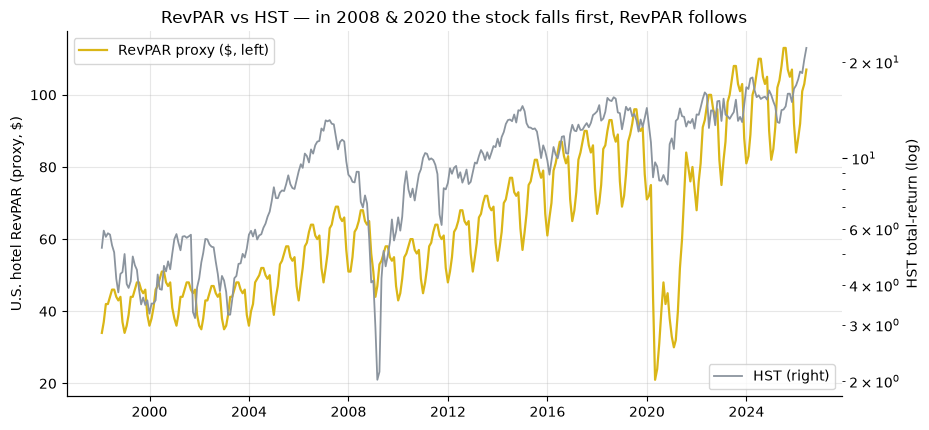

RevPAR YoY momentum: mean 0.033 std 0.244 frac>0 0.77


In [2]:
if HAVE_REAL:
    fig, ax1 = plt.subplots(figsize=(9.4, 4.4))
    ax1.plot(F.index, F['revpar'], c=AMBER, lw=1.6, label='RevPAR proxy ($, left)')
    ax1.set_ylabel('U.S. hotel RevPAR (proxy, $)')
    ax2 = ax1.twinx(); ax2.plot(F.index, F['px'], c=GREY, lw=1.3, label='HST (right)')
    ax2.set_yscale('log'); ax2.grid(False); ax2.set_ylabel('HST total-return (log)')
    ax1.set_title('RevPAR vs HST — in 2008 & 2020 the stock falls first, RevPAR follows')
    ax1.legend(loc='upper left'); ax2.legend(loc='lower right'); plt.tight_layout(); plt.show()
    m = st.revpar_momentum(F)
    print('RevPAR YoY momentum: mean', round(m.mean(),3), 'std', round(m.std(),3), 'frac>0', round((m>0).mean(),2))
else:
    print('no cache — see docs/results.md: momentum mean', R['mom_mean'], 'frac>0', R['mom_frac_pos'], '%')

RevPAR grows year-on-year about **77%** of months — it's an up-trending, cyclical series, like the hotels' business. Now the real question: when it's growing, does the stock pay *more* next — or has it already moved?

**The payoff vs a normal month.** For each horizon, the average forward HST return after an upcycle month, next to a downcycle month and the unconditional base rate.

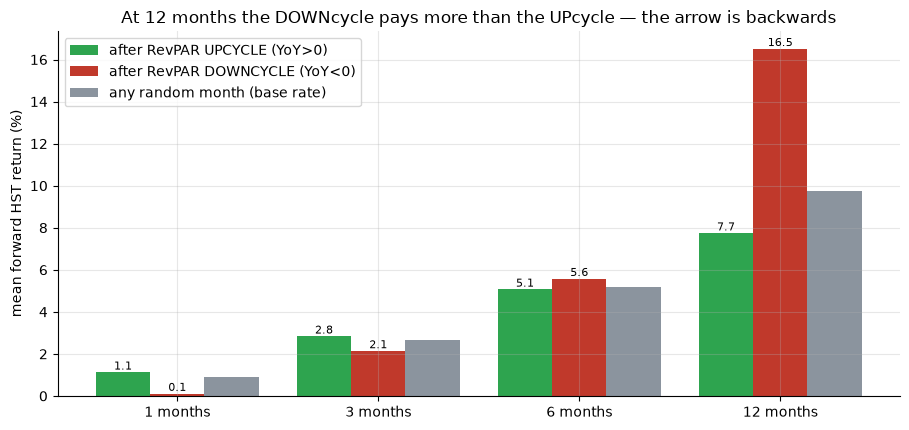

12m: upcycle 7.7 % vs downcycle 16.5 % vs base 9.8 %


In [3]:
hs = [1, 3, 6, 12]
if HAVE_REAL:
    up = [st.summarize(F, m)['up_mean']*100 for m in hs]
    dn = [st.summarize(F, m)['dn_mean']*100 for m in hs]
    ba = [st.summarize(F, m)['base_mean']*100 for m in hs]
else:
    up = [R['h1'][2], R['h3'][2], R['h6'][2], R['h12'][2]]
    dn = [R['h1'][3], R['h3'][3], R['h6'][3], R['h12'][3]]
    ba = [R['h1'][4], R['h3'][4], R['h6'][4], R['h12'][4]]
x = np.arange(len(hs))
fig, ax = plt.subplots(figsize=(9.2, 4.4))
ax.bar(x-.27, up, .27, color=GREEN, label='after RevPAR UPCYCLE (YoY>0)')
ax.bar(x, dn, .27, color=RED, label='after RevPAR DOWNCYCLE (YoY<0)')
ax.bar(x+.27, ba, .27, color=GREY, label='any random month (base rate)')
ax.set_xticks(x); ax.set_xticklabels([f'{m} months' for m in hs])
ax.set_ylabel('mean forward HST return (%)')
ax.set_title('At 12 months the DOWNcycle pays more than the UPcycle — the arrow is backwards')
for i,(u,d) in enumerate(zip(up,dn)):
    ax.annotate(f'{u:.1f}',(i-.27,u),ha='center',va='bottom',fontsize=8)
    ax.annotate(f'{d:.1f}',(i,d),ha='center',va='bottom',fontsize=8)
ax.legend(); plt.tight_layout(); plt.show()
print('12m: upcycle', round(up[-1],1), '% vs downcycle', round(dn[-1],1), '% vs base', round(ba[-1],1), '%')

There's the surprise. At short horizons the upcycle bump is a whisker — **+1.1%** vs a **+0.9%** base at 1 month. And at 12 months it **flips**: after a RevPAR boom, HST returns **+7.8%**, but after a RevPAR *bust* it returns **+16.5%** — more than double. Buying when travel is roaring is buying the *late* cycle. The folklore has the sign wrong.

**So who actually moves first?** This is the cleanest test. We slide RevPAR momentum against the stock return at every lead and lag. If RevPAR *leads*, the correlation peaks to the **right** (positive lead). If the *stock* leads, it peaks to the **left**.

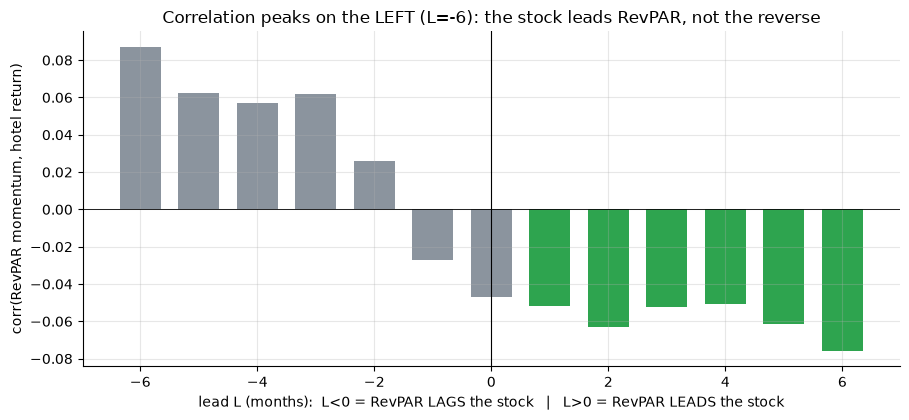

peak correlation at L = -6 (negative L => the equity moved first)


In [4]:
if HAVE_REAL:
    ll = st.lead_lag(F); Ls = list(ll.index); cs = list(ll.values)
else:
    Ls = [l for l,_ in R['leadlag']]; cs = [c for _,c in R['leadlag']]
fig, ax = plt.subplots(figsize=(9.2, 4.3))
colors = [GREEN if L>0 else GREY for L in Ls]
ax.bar(Ls, cs, color=colors, width=.7)
ax.axvline(0, c='k', lw=.8); ax.axhline(0, c='k', lw=.6)
ax.set_xlabel('lead L (months):  L<0 = RevPAR LAGS the stock   |   L>0 = RevPAR LEADS the stock')
ax.set_ylabel('corr(RevPAR momentum, hotel return)')
ax.set_title('Correlation peaks on the LEFT (L=-6): the stock leads RevPAR, not the reverse')
plt.tight_layout(); plt.show()
peakL = Ls[int(np.argmax(cs))]
print('peak correlation at L =', peakL, '(negative L => the equity moved first)')

The tallest green-or-grey bar sits at **L = −6**: RevPAR momentum lines up best with the hotel return from **six months earlier**. Every *positive* lead (RevPAR supposedly leading) has a **negative** correlation. In plain terms: **the hotel stock moves first, and RevPAR confirms it half a year later.** A leading indicator that lags is not a leading indicator.

## 5 · The verdict

- **Signal — None.** The claimed *positive lead* isn't there: the upcycle bump is ~0 at 1–3 months, and at 6–12 months it **inverts** (downcycle months pay more — **+16.5%** vs **+7.8%** at a year). High RevPAR YoY is a late-cycle tell, not a buy trigger.
- **Tradability — Fragile.** A "hold hotels while RevPAR is growing" overlay does top buy-and-hold (Sharpe **0.45** vs **0.31**) — but only by sitting out the 2008 and 2020 crashes on **8 switches in 28 years**. Two lucky regime calls, not a repeatable edge.
- **Leading indicator? — Busted.** The stock leads RevPAR by ~6 months. RevPAR is a coincident-to-lagging confirmation of the travel cycle, not the early read the folklore sells.

## 6 · Could you actually trade it? — race it against buy-and-hold

Set significance aside and ask the operational question: if you hold the hotel stock only while RevPAR is growing year-on-year and step aside otherwise, do you beat simply owning it? Here's the Sharpe of each rule next to plain buy-and-hold.

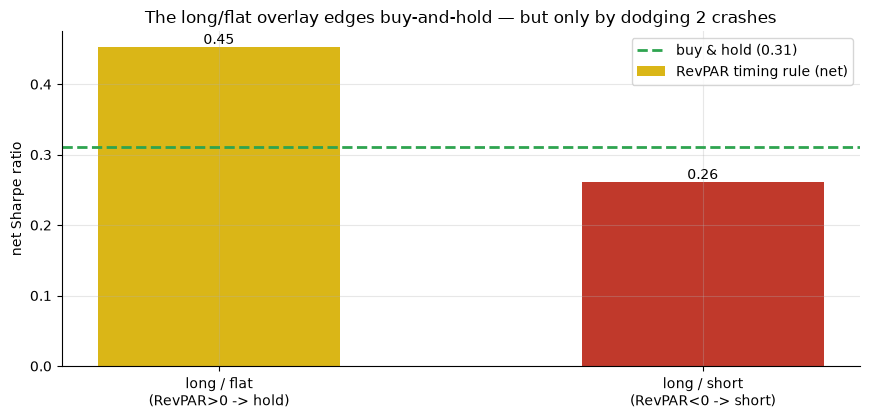

long/flat Sharpe 0.45 vs buy&hold 0.31; long/short 0.26


In [5]:
if HAVE_REAL:
    bl = []
    for short in (False, True):
        b = st.timing_backtest(F, cost_bps=10.0, allow_short=short)
        bl.append((b['net']['sharpe'], b['buy_hold']['sharpe']))
    rule_sh = [bl[0][0], bl[1][0]]; bh = bl[0][1]
else:
    rule_sh = [R['timing'][0][4], R['timing'][1][4]]; bh = R['timing'][0][5]
labels = ['long / flat\n(RevPAR>0 -> hold)', 'long / short\n(RevPAR<0 -> short)']
x = np.arange(len(labels))
fig, ax = plt.subplots(figsize=(8.8, 4.3))
ax.bar(x, rule_sh, .5, color=[AMBER, RED], label='RevPAR timing rule (net)')
ax.axhline(bh, ls='--', c=GREEN, lw=2, label=f'buy & hold ({bh:.2f})')
ax.set_xticks(x); ax.set_xticklabels(labels); ax.set_ylabel('net Sharpe ratio')
ax.set_title('The long/flat overlay edges buy-and-hold — but only by dodging 2 crashes')
for i,s in enumerate(rule_sh): ax.annotate(f'{s:.2f}',(i,s),ha='center',va='bottom')
ax.legend(); plt.tight_layout(); plt.show()
print(f'long/flat Sharpe {rule_sh[0]:.2f} vs buy&hold {bh:.2f}; long/short {rule_sh[1]:.2f}')

The long/flat rule's Sharpe (**0.45**) does beat buy-and-hold (**0.31**) — and ends richer (**9.0×** vs **4.2×** on $1). But it makes only **8 switches** in 28 years: essentially it *sat out the 2008 and 2020 hotel crashes*, when RevPAR YoY went deeply negative. That's two regime calls, and — because the stock leads RevPAR — in real time you'd have de-risked *after* the drop. Betting *against* hotels on downcycles (long/short) collapses to **0.26**. This is a slow crash filter that got lucky twice, not a tradable RevPAR signal.

## 7 · Going further 🚪

- **The leading-indicator pattern.** ISM-PMI, jobless-claims and economic-surprise studies on this bench all rhyme: a gauge the market already discounts is a coincident-or-lagging tell, and the stock tends to *lead* the fundamental series it reflects.
- **A licensed RevPAR tape.** Swap our proxy for STR's real monthly RevPAR (by chain scale / market) and the lead-lag test should sharpen — but the direction (equity leads the print) is set by the release lag and by discounting, and won't reverse.
- **Forward bookings, not realized RevPAR.** If any hotel data *leads*, it's forward bookings / search demand — the *expectation*, not the realized print. That's the series worth chasing; the reported RevPAR headline is already in the price.

*Think RevPAR momentum leads hotel stocks? Rebuild the momentum, line it up against the tape at every lead, and show the correlation peaking on the **right** (RevPAR first) **and** an upcycle rule paying a positive, significant excess — then we'll talk.*